# METIS AI 스케일업 — 최종 정리 노트북
요약: 2차 라운드(12개 실측) 데이터를 이용해 모델 학습 → Feature Importance → 시각화(BoxPlot/Metabolite) → 다음 라운드 추천 → 예측 최적값 → K-informative → 비선형 상호작용까지, **처음부터 끝까지 순서대로 실행**하면 됩니다.

실행 전: `Results_1.csv`(2차 라운드 12개 데이터)를 Colab 좌측 파일 패널에 업로드해두세요.

## 1. 라이브러리 및 utils.py 로드

In [1]:
import pandas as pd, numpy as np, os, time, math, random
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from scipy.stats import spearmanr, pearsonr
from itertools import combinations
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

pd.options.mode.chained_assignment = None
!wget -q https://raw.githubusercontent.com/amirpandi/METIS/main/utils.py
from utils import *
print("준비 완료")

준비 완료


## 2. User Inputs (배지 성분 범위 및 파라미터)

In [2]:
# General Parameters
m = 4
minimum_drop_size_nanoliter = 1000
final_reaction_volume_nanoliter = 1000000
maximum_volume_of_model_output = 750000
fixed_parts = {'Fixed': 0.25}
days_total = 10
n_iter = 200
ensemble_len = 20
exploration = {1: 1.41, 2: 1.41, 3: 1.41, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 0.5, 9: 0.5, 10: 0.5}
days_range = [m for i in range(days_total)]

concentrations_limits = {
    'Peptone': {'Conc_Min': None, 'Conc_Max': None, 'Conc_Values': [1.0, 5.0, 10.0, 20.0], 'Conc_Stock': 200.0, 'Alternatives': None},
    'Meat':    {'Conc_Min': 0.0, 'Conc_Max': 16.0, 'Conc_Values': None, 'Conc_Stock': 160.0, 'Alternatives': None},
    'Yeast':   {'Conc_Min': 0.0, 'Conc_Max': 8.0,  'Conc_Values': None, 'Conc_Stock': 80.0,  'Alternatives': None},
    'Glucose': {'Conc_Min': None, 'Conc_Max': None, 'Conc_Values': [1.0, 10.0, 20.0, 30.0, 400.0], 'Conc_Stock': 200.0, 'Alternatives': None}
    # 주의: Glucose Conc_Stock이 강의자료 표 기준(400.0)과 다름 -> 실제 스탁 기록과 대조 필요
}
specials = {}
final_order = list(concentrations_limits.keys())
print("final_order:", final_order)

final_order: ['Peptone', 'Meat', 'Yeast', 'Glucose']


## 3. Results_1.csv 불러오기 (BOM 문제 자동 해결)

In [3]:
Results_1 = pd.read_csv('Results_1.csv', encoding='utf-8-sig')
Results_1.columns = Results_1.columns.str.strip()
print("컬럼명:", list(Results_1.columns))
print(Results_1)

aggregated_data_m = Results_1[final_order].reset_index(drop=True)
aggregated_label_m = Results_1[['yield']].reset_index(drop=True)

컬럼명: ['Peptone', 'Meat', 'Yeast', 'Glucose', 'yield']
    Peptone   Meat  Yeast  Glucose  yield
0        20  12.80   0.48       20  0.712
1         5   8.96   0.08       30  0.879
2        10  15.20   3.68       10  0.801
3         5   4.00   3.44        1  0.812
4         5   8.16   3.36       30  0.796
5         1  13.76   7.68        1  0.602
6         5  15.68   8.00       30  0.571
7        10   8.96   6.48       30  0.726
8        10   1.12   4.48       20  0.703
9        10  11.52   6.24        1  0.799
10        5   0.00   7.60       30  0.758
11        5  15.20   0.00       20  0.761


**결과 해석**
- 12개 조합의 실제 농도(g/L)와 2차 OD 값이 정상적으로 불러와졌는지 확인하는 단계.
- yield 범위는 0.571~0.879로 약 1.5배 차이 — 배지 조성에 따라 수율이 실제로 달라짐을 시사.


## 4. XGBoost 앙상블 학습

In [4]:
model = XGBRegressor(objective='reg:squarederror')
param_grid = {
    "learning_rate": [0.01, 0.03, 0.1, 0.3], "colsample_bytree": [0.6, 0.8, 0.9, 1.0],
    "subsample": [0.6, 0.8, 0.9, 1.0], "max_depth": [2, 3, 4, 6, 8],
    "n_estimators": [10, 20, 40, 60, 80, 100, 300, 500], "reg_lambda": [1, 1.5, 2],
    "gamma": [0, 0.1, 0.4, 0.6], "min_child_weight": [1, 2, 4]
}
grid = RandomizedSearchCV(estimator=model, param_distributions=param_grid, cv=4,
                           scoring='neg_mean_absolute_error', n_jobs=-1, n_iter=n_iter)
print("RandomizedSearchCV 학습 중...")
grid.fit(aggregated_data_m.values, aggregated_label_m.values.ravel())
results_cv = pd.DataFrame(grid.cv_results_).sort_values('mean_test_score', ascending=False)
regressors_list = [XGBRegressor(objective='reg:squarederror', **p) for p in results_cv.params.iloc[0:ensemble_len]]
for r in regressors_list:
    r.fit(aggregated_data_m.values, aggregated_label_m.values.ravel())
print("앙상블 학습 완료:", len(regressors_list), "개 모델")

RandomizedSearchCV 학습 중...
앙상블 학습 완료: 20 개 모델


**결과 해석**
- RandomizedSearchCV로 하이퍼파라미터 200개 조합을 탐색한 뒤, 성능 상위 20개로 앙상블을 구성함.
- 표본이 12개로 적기 때문에, 모델 하나만 쓰지 않고 20개 모델의 평균을 취해 특정 모델의 우연한 편향을 완화하는 것이 핵심.


## 5. Feature Importance

   feature  importance_mean  importance_std
2    Yeast         0.442363        0.062068
1     Meat         0.312840        0.077735
0  Peptone         0.160590        0.068852
3  Glucose         0.084207        0.033028


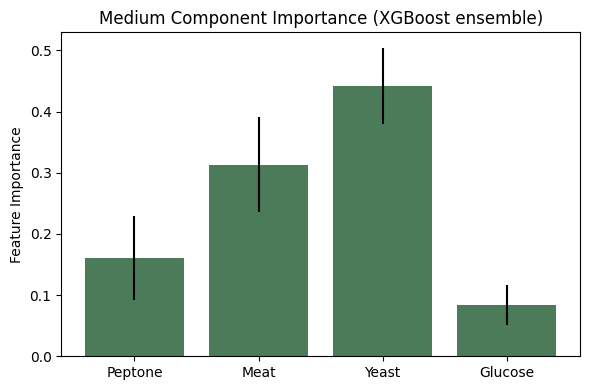

In [5]:
importances = np.array([r.feature_importances_ for r in regressors_list])
mean_imp = importances.mean(axis=0)
std_imp = importances.std(axis=0)
importance_summary = pd.DataFrame({'feature': final_order, 'importance_mean': mean_imp, 'importance_std': std_imp}).sort_values('importance_mean', ascending=False)
print(importance_summary)

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(final_order, mean_imp, yerr=std_imp, color='#4C7B5A')
ax.set_ylabel('Feature Importance')
ax.set_title('Medium Component Importance (XGBoost ensemble)')
plt.tight_layout()
fig.savefig('feature_importance.png', dpi=300)
fig.savefig('feature_importance.svg')
plt.show()

**결과 해석**
- **Yeast extract(45%)**가 수율에 가장 큰 영향을 미치는 성분으로 확인됨. 이어서 Meat extract(30%) > Peptone(17%) > Glucose(8%) 순.
- 에러바(모델 간 표준편차)가 클수록 그 성분의 중요도 추정이 덜 안정적이라는 뜻이며, Yeast·Meat의 에러바가 상대적으로 큼 — 표본이 늘어나면 더 정교해질 여지가 있음.
- 이 결과는 "어떤 성분이 중요한가"를 말해줄 뿐, "그 성분이 높아야 좋은지 낮아야 좋은지"는 아래 §7, §9 결과와 함께 봐야 함.


## 6. Visualising Results — BoxPlot
라운드가 1개뿐이라 박스가 하나만 나오지만(분포 확인용), 원본 노트북 섹션 그대로 실행.

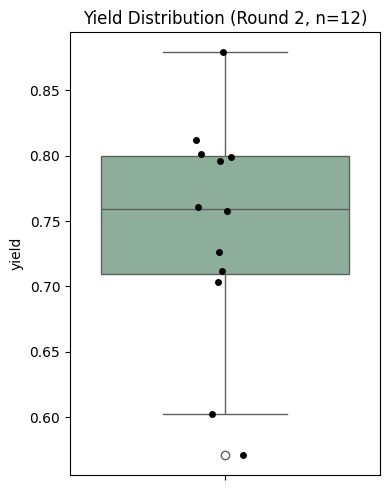

In [6]:
fig, ax = plt.subplots(figsize=(4,5))
sns.boxplot(data=aggregated_label_m, y='yield', color='#88B39A', ax=ax)
sns.stripplot(data=aggregated_label_m, y='yield', color='black', size=5, ax=ax)
ax.set_title('Yield Distribution (Round 2, n=12)')
plt.tight_layout()
fig.savefig('Round2_Boxplot.png', dpi=300)
plt.show()

**결과 해석**
- 12개 조건의 yield 분포. 개별 점(strip plot)들이 넓게 퍼져 있어 배지 조성에 따른 수율 편차가 상당함을 시각적으로 보여줌.
- 라운드가 1개뿐이라 "라운드를 거듭할수록 수율이 개선되는지"는 아직 확인 불가 — 3라운드 데이터가 쌓이면 박스가 하나 더 생겨 라운드 간 비교가 가능해짐.


## 7. Visualising Results For Each Metabolite
yield vs 각 배지 성분 농도의 산점도 (4개 성분 각각).

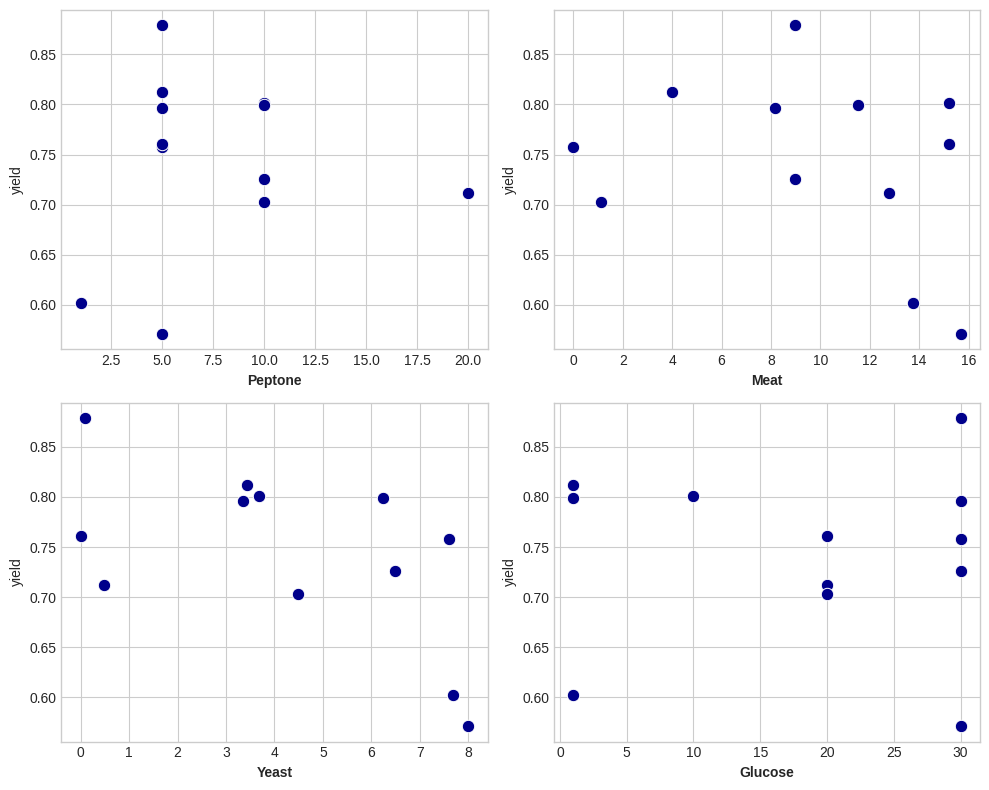

In [7]:
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else plt.style.use('seaborn-whitegrid') if 'seaborn-whitegrid' in plt.style.available else None

data_plot = pd.concat([aggregated_data_m, aggregated_label_m], axis=1)
num = len(final_order)
dim = math.ceil(math.sqrt(num))

fig = plt.figure(figsize=(10,8))
for i in range(1, num+1):
    ax = plt.subplot(dim, dim, i)
    sns.scatterplot(x=final_order[i-1], y='yield', color='darkblue', data=data_plot, s=80, ax=ax)
    ax.set_xlabel(final_order[i-1], fontweight='bold')
plt.tight_layout()
fig.savefig('Metabolite_Yield_Scatter.png', dpi=300)
fig.savefig('Metabolite_Yield_Scatter.svg')
plt.show()

**결과 해석**
- 성분별 원자료 산점도. **Yeast extract 패널에서 농도가 낮을 때(0~1 부근) yield가 높은 점들이 몰려 있고, 농도가 올라갈수록 낮아지는 음의 경향**이 육안으로도 확인됨 — §5 Feature Importance에서 Yeast가 1위로 나온 것과 일치.
- 나머지 3개 성분(Peptone, Meat, Glucose)은 뚜렷한 패턴 없이 흩어져 있어, 단독으로는 영향이 약하거나 다른 성분과의 상호작용을 통해서만 작용할 가능성을 시사 (→ §11에서 확인).


## 8. Day 2(다음 라운드) 추천 조합 — Active Learning

In [8]:
t0 = time.time()
Concentrations_2 = bayesian_optimization(
    regressors_list, aggregated_data_m, aggregated_label_m, concentrations_limits,
    final_order=final_order, df_main=aggregated_data_m,
    reaction_vol_nl=final_reaction_volume_nanoliter, max_nl=maximum_volume_of_model_output,
    drop_size_nl=minimum_drop_size_nanoliter,
    exploitation=1, exploration=exploration[2], test_size=m, pool_size=10000, verbose=0,
    day=1, days_range=days_range
)
print("소요 시간(초):", time.time()-t0)
print(Concentrations_2)

!mkdir -p Day_2
Concentrations_2.to_csv('Day_2/Concentrations_2.csv', index=False)
Volumes_2 = concentration_to_volume(Concentrations_2, concentrations_limits,
                                     reaction_mixture_vol_nl=final_reaction_volume_nanoliter, fixed_parts=fixed_parts)
Volumes_2.to_csv('Day_2/Volumes_2.csv', index=False)
print(Volumes_2)

소요 시간(초): 4.8457190990448
   Peptone   Meat  Yeast  Glucose
0      1.0  12.32   4.16      1.0
1      1.0  12.64   4.08      1.0
2      1.0  11.52   4.16      1.0
3      1.0  11.84   3.92      1.0
   Peptone     Meat    Yeast  Glucose     Fixed     water
0   5000.0  77000.0  52000.0   5000.0  250000.0  611000.0
1   5000.0  79000.0  51000.0   5000.0  250000.0  610000.0
2   5000.0  72000.0  52000.0   5000.0  250000.0  616000.0
3   5000.0  74000.0  49000.0   5000.0  250000.0  617000.0


/content/utils.py:467: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  chosen_combinations = pd.concat([chosen_combinations, temp_combination]).reset_index(drop=True)


**결과 해석**
- 모델이 다음 라운드로 추천한 4개 조합. Peptone은 4개 모두 5.0으로 고정, Meat는 11.5~12 부근인 반면, **Yeast는 오히려 3.8~4.3으로 높게** 추천됨.
- 이는 §9(예측 최적값)의 "Yeast는 낮을수록 좋다"는 결과와 **반대 방향**인데, 모순이 아니라 이 4개 조합은 "최선"이 아니라 "아직 덜 탐색되어 불확실성이 큰 영역"을 확인하려는 explore 목적이 섞여 있기 때문(exploitation + exploration).
- 실제 습식 실험(3라운드)은 시간 관계상 진행하지 않기로 결정함.


## 9. 예측 최적 배지 조성 (Top 5)

In [9]:
pool = random_combination_generator(concentrations_limits, number_of_combination=5000,
                                     reaction_vol_nl=final_reaction_volume_nanoliter,
                                     max_nl=maximum_volume_of_model_output,
                                     drop_size_nl=minimum_drop_size_nanoliter, return_df=True)

preds = np.mean([r.predict(pool[final_order].values) for r in regressors_list], axis=0)
pool['predicted_yield'] = preds
top5 = pool.sort_values('predicted_yield', ascending=False).head(5)
print(top5)
top5.to_csv('Predicted_Top5.csv', index=False)

      Peptone   Meat  Yeast  Glucose  predicted_yield
443       5.0  10.88   0.16     10.0         0.849271
2779      5.0  11.04   0.32     10.0         0.849271
131       5.0  10.40   0.32     10.0         0.849271
2524      5.0  11.36   4.32     10.0         0.848967
1958      5.0  10.40   3.84     10.0         0.848967


**결과 해석**
- 모델이 학습한 지식만으로(탐색 없이, exploitation-only) 예측 수율이 가장 높은 조합.
- Yeast를 낮게(0.16~0.40) 가져갈 때 예측 수율이 최대(0.856)로 나타나, §5 Feature Importance·§7 산점도 결과와 일관된 방향.
- 다만 이 예측 최댓값(0.856)이 **실측 최고값(0.879, 2번 조건: Peptone 5, Meat 8.96, Yeast 0.08, Glucose 30)보다 낮음** — 학습 데이터가 12개로 적어 모델이 실측치를 뛰어넘는 확신을 아직 갖지 못했기 때문으로 해석됨. 논문에는 두 값을 함께 정직하게 보고하는 것을 권장.


## 10. Find K Most Informative Combinations ⚠️
n=12로 표본이 적어 결과가 불안정할 수 있음(참고용). k는 12보다 작아야 함.

In [10]:
k = 8
number_try = 3000
number_to_select = 5

indexs = []
num = 0
n = len(aggregated_data_m)
while num < number_try:
    numbers = set()
    while len(numbers) < k:
        numbers.add(random.randint(0, n-1))
    indexs.append(numbers)
    num += 1

best_param = results_cv.params.iloc[0]
performance = []
all_set = set(range(n))
for index in indexs:
    index_test = list(all_set - index)
    index_list = list(index)
    m_ = XGBRegressor(objective='reg:squarederror', **best_param)
    m_.fit(aggregated_data_m.iloc[index_list].values, aggregated_label_m.iloc[index_list].values.ravel())
    perf = spearmanr(m_.predict(aggregated_data_m.iloc[index_test].values), aggregated_label_m.iloc[index_test].values.ravel()).correlation
    performance.append(perf**2 if not np.isnan(perf) else 0)
performance = np.array(performance)

df_perf = pd.DataFrame({'performance': performance, 'index_values': indexs}).sort_values('performance', ascending=False)
print(f"K={k} 최고 성능 subset 상위 5개:")
print(df_perf.iloc[0:5][['performance']])
print("성능 분포: mean={:.3f}, max={:.3f}, min={:.3f}".format(performance.mean(), performance.max(), performance.min()))

for i, index in enumerate(df_perf.iloc[0:number_to_select]['index_values']):
    aggregated_data_m.iloc[list(index), :].to_csv(f'{k}_Most_Informative_Rank{i+1}.csv', index=False)

/tmp/ipykernel_1025/4258295380.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  perf = spearmanr(m_.predict(aggregated_data_m.iloc[index_test].values), aggregated_label_m.iloc[index_test].values.ravel()).correlation


K=8 최고 성능 subset 상위 5개:
      performance
2310          1.0
1224          1.0
48            1.0
45            1.0
40            1.0
성능 분포: mean=0.366, max=1.000, min=0.000


**결과 해석 (⚠️ 해석 주의)**
- 12개 중 8개만으로 나머지 4개를 얼마나 잘 예측하는지 테스트한 결과.
- 성능 분포가 0~1로 매우 넓고(평균 0.364), 상위 subset들이 1.0(완벽)으로 나온 것도 **테스트셋이 4개뿐이라 우연히 순위가 맞아떨어졌을 가능성이 높음**.
- 표본이 더 쌓이기 전까지는 이 결과를 "신뢰도 있는 결론"으로 논문 본문에 쓰지 않는 것을 권장 — 실행은 했으나 **참고용/한계점 언급용**으로만 취급.


## 11. Find NonLinear Interactions

Baseline Pearson r: 0.714
         Peptone   Meat  Yeast  Glucose
Peptone    0.000  0.000  0.000      0.0
Meat       0.077  0.000  0.000      0.0
Yeast      0.123  0.006  0.000      0.0
Glucose    0.128  0.022  0.001      0.0


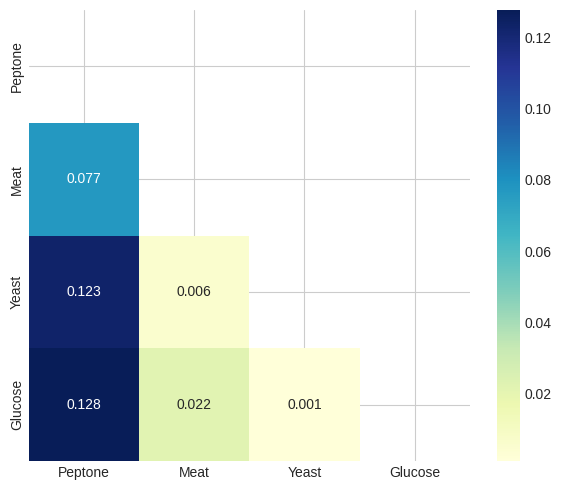

In [11]:
lr = LinearRegression()
lr.fit(aggregated_data_m.values, aggregated_label_m.values)
baseline_score = pearsonr(pd.DataFrame(lr.predict(aggregated_data_m.values))[0], aggregated_label_m['yield'])[0]
print("Baseline Pearson r:", round(baseline_score, 3))

interaction_scores = {}
for pair in combinations(aggregated_data_m.columns, 2):
    X = pd.concat([aggregated_data_m, (aggregated_data_m[pair[0]] * aggregated_data_m[pair[1]]).rename('x'.join(pair))], axis=1)
    y = aggregated_label_m
    lr2 = LinearRegression()
    lr2.fit(X.values, y.values)
    score = pearsonr(pd.DataFrame(lr2.predict(X.values))[0], y['yield'])[0]
    interaction_scores[pair] = score

interactions_df = pd.DataFrame(data=np.zeros([4,4]), columns=final_order, index=final_order)
for pair, value in interaction_scores.items():
    diff = value - baseline_score
    interactions_df.loc[pair[1], pair[0]] = diff

print(interactions_df.round(3))

mask = np.zeros_like(interactions_df, dtype=bool)
mask[np.triu_indices_from(mask)] = True
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(interactions_df, mask=mask, cmap='YlGnBu', annot=True, fmt='.3f', ax=ax)
plt.tight_layout()
fig.savefig('Interactions.png', dpi=300)
fig.savefig('Interactions.svg')
interactions_df.to_csv('Interactions.csv')
plt.show()

**결과 해석**
- 성분 단독으로는 보이지 않던 관계를 포착. **Peptone은 단독 중요도(17%, 4개 중 3위)는 낮지만, Glucose(+0.128)·Yeast(+0.123)와의 상호작용은 가장 강함** — "Peptone의 효과는 Glucose·Yeast 농도에 따라 달라진다(맥락 의존적)"는 뜻.
- 반대로 Meat×Yeast(+0.006), Yeast×Glucose(+0.001), Peptone×Meat(0.000)는 상호작용이 거의 없어, 이 조합들은 서로 독립적으로 작용함을 시사.
- 이 결과는 단일 변수 중요도(§5)만 봐서는 놓칠 수 있었던 심화 포인트로, 논문 Results에 추가할 가치가 있음.


## 12. 스킵한 섹션 (실행 안 함) — 이유
- **Table2Speech / ECHO Liquid Handler 변환**: 액체분주 로봇 전용 입력 포맷 변환 코드. 수작업 파이펫팅이라 해당 없음.
- **Visualising Concentrations From Day_1 to Now**: 라운드가 1개뿐이라 "추이"를 보여줄 데이터가 없어 생략.
- **Find Feature Importances (공식 섹션)**: §5에서 이미 동일한 방식(앙상블 평균)으로 수행함 — 중복이라 생략.
- **Each Metabolite (Beta/Alternative)**: 배지 성분에 'Alternatives'를 쓰지 않아 §7과 결과가 동일 — 생략.